Ticker            AAPL        META        MSFT        NVDA
Date                                                      
2026-09-17  337.000000  681.771973  497.750000  219.339996
2026-09-18  336.130005  665.225037  493.779999  222.270004
2026-09-21  338.980011  741.250000  501.609985  227.380005
2026-09-22  339.750000  736.599976  498.000000  228.869995
2026-09-23  337.019989  744.099976  500.589996  225.509995


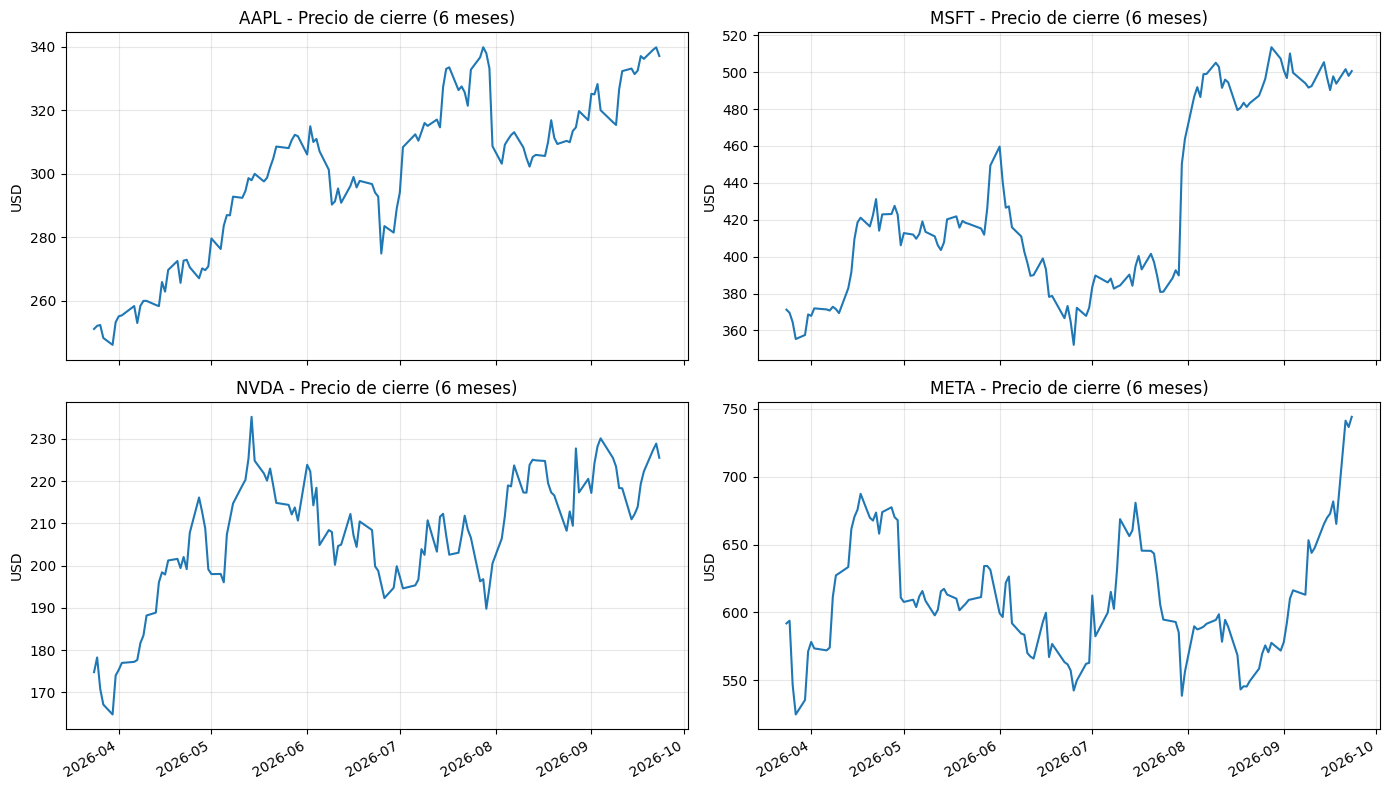

In [2]:
import yfinance as yf
import matplotlib.pyplot as plt

tickers = ["AAPL", "MSFT", "NVDA", "META"]

# Descarga de datos (6 meses, diario)
data = yf.download(tickers, period="6mo", interval="1d", auto_adjust=True, progress=False)
close = data["Close"]
if close.dropna(how="all").empty:
    raise SystemExit("No se descargaron datos. Revisa tu conexión a internet (o un error de certificado SSL).")

# Guardar los datos en CSV
data.to_csv("datos_6m.csv")
print(close.tail())

# Una gráfica de Close para cada acción
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
for ax, t in zip(axes.flat, tickers):
    ax.plot(close.index, close[t], linewidth=1.5)
    ax.set_title(f"{t} - Precio de cierre (6 meses)")
    ax.set_ylabel("USD")
    ax.grid(alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [6]:
import pandas as pd

R = 0.04           # tasa libre de riesgo anual (ajústala a la tasa vigente)
N_SIMS = 50_000    # trayectorias de Monte Carlo
SEED = 42

def black_scholes(S0, K, r, sigma, T):
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    call = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    put = K * np.exp(-r * T) * norm.cdf(-d2) - S0 * norm.cdf(-d1)
    return call, put


def simular_gbm(S0, r, sigma, T, n_steps, n_sims, seed=SEED):
    """Trayectorias bajo la medida neutral al riesgo. Regresa matriz (n_sims, n_steps + 1)."""
    rng = np.random.default_rng(seed)
    dt = T / n_steps
    Z = rng.standard_normal((n_sims, n_steps))
    log_inc = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
    log_paths = np.cumsum(log_inc, axis=1)
    return S0 * np.exp(np.hstack([np.zeros((n_sims, 1)), log_paths]))


def payoffs(paths, K):
    """Payoffs de cada tipo de opción. `paths` puede ser una sola trayectoria (1D) o muchas (2D)."""
    paths = np.atleast_2d(paths)
    ST = paths[:, -1]
    promedio = paths[:, 1:].mean(axis=1)   # Asiática: promedio aritmético, strike fijo K
    maximo = paths.max(axis=1)
    minimo = paths.min(axis=1)             # Lookback: strike flotante
    return {
        ("Europea", "Call"): np.maximum(ST - K, 0),
        ("Europea", "Put"): np.maximum(K - ST, 0),
        ("Asiática", "Call"): np.maximum(promedio - K, 0),
        ("Asiática", "Put"): np.maximum(K - promedio, 0),
        ("Lookback", "Call"): ST - minimo,
        ("Lookback", "Put"): maximo - ST,
    }


def valuar(precios: pd.Series, r=R, n_sims=N_SIMS):
    precios = precios.dropna()
    S0 = precios.iloc[0]
    K = S0                                             # opción at-the-money
    n_steps = len(precios) - 1
    T = n_steps / 252
    sigma = np.log(precios).diff().dropna().std() * np.sqrt(252)

    sims = payoffs(simular_gbm(S0, r, sigma, T, n_steps, n_sims), K)
    reales = payoffs(precios.to_numpy(), K)
    descuento = np.exp(-r * T)

    filas = []
    for (tipo, clase), pago in sims.items():
        filas.append({
            "Tipo": tipo,
            "Clase": clase,
            "Prima MC": descuento * pago.mean(),
            "Error std": descuento * pago.std() / np.sqrt(n_sims),
            "Payoff real": reales[(tipo, clase)][0],
        })
    tabla = pd.DataFrame(filas)
    tabla["Ganancia neta"] = tabla["Payoff real"] - tabla["Prima MC"] / descuento
    bs_call, bs_put = black_scholes(S0, K, r, sigma, T)
    return tabla, {"S0": S0, "K": K, "ST": precios.iloc[-1], "sigma": sigma, "T": T,
                   "BS call": bs_call, "BS put": bs_put}


if __name__ == "__main__":
    data = yf.download(tickers, period="6mo", interval="1d", auto_adjust=True, progress=False)
    close = data["Close"]
    if close.dropna(how="all").empty:
        raise SystemExit("No se descargaron datos. Revisa tu conexión a internet (o un error de certificado SSL).")

    pd.set_option("display.float_format", "{:,.2f}".format)
    resultados = []
    for t in TICKERS:
        tabla, info = valuar(close[t])
        print(f"\n===== {t} =====")
        print(f"S0 = {info['S0']:.2f} | K = {info['K']:.2f} | S_T (hoy) = {info['ST']:.2f} | "
              f"sigma = {info['sigma']:.2%} | T = {info['T']:.3f} años | r = {R:.2%}")
        print(f"Black-Scholes -> Call: {info['BS call']:.2f}  Put: {info['BS put']:.2f}")
        print(tabla.to_string(index=False))
        resultados.append(tabla.assign(Ticker=t))

    pd.concat(resultados).to_csv("valuacion_opciones.csv", index=False)
    print("\nResultados guardados en valuacion_opciones.csv")

NameError: name 'TICKERS' is not defined

In [ ]:
import pandas as pd

R = 0.04           # tasa libre de riesgo anual (ajústala a la tasa vigente)
N_SIMS = 50_000    # trayectorias de Monte Carlo
SEED = 42

def black_scholes(S0, K, r, sigma, T):
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    call = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    put = K * np.exp(-r * T) * norm.cdf(-d2) - S0 * norm.cdf(-d1)
    return call, put


def simular_gbm(S0, r, sigma, T, n_steps, n_sims, seed=SEED):
    """Trayectorias bajo la medida neutral al riesgo. Regresa matriz (n_sims, n_steps + 1)."""
    rng = np.random.default_rng(seed)
    dt = T / n_steps
    Z = rng.standard_normal((n_sims, n_steps))
    log_inc = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
    log_paths = np.cumsum(log_inc, axis=1)
    return S0 * np.exp(np.hstack([np.zeros((n_sims, 1)), log_paths]))


def payoffs(paths, K):
    """Payoffs de cada tipo de opción. `paths` puede ser una sola trayectoria (1D) o muchas (2D)."""
    paths = np.atleast_2d(paths)
    ST = paths[:, -1]
    promedio = paths[:, 1:].mean(axis=1)   # Asiática: promedio aritmético, strike fijo K
    maximo = paths.max(axis=1)
    minimo = paths.min(axis=1)             # Lookback: strike flotante
    return {
        ("Europea", "Call"): np.maximum(ST - K, 0),
        ("Europea", "Put"): np.maximum(K - ST, 0),
        ("Asiática", "Call"): np.maximum(promedio - K, 0),
        ("Asiática", "Put"): np.maximum(K - promedio, 0),
        ("Lookback", "Call"): ST - minimo,
        ("Lookback", "Put"): maximo - ST,
    }


def valuar(precios: pd.Series, r=R, n_sims=N_SIMS):
    precios = precios.dropna()
    S0 = precios.iloc[0]
    K = S0                                             # opción at-the-money
    n_steps = len(precios) - 1
    T = n_steps / 252
    sigma = np.log(precios).diff().dropna().std() * np.sqrt(252)

    sims = payoffs(simular_gbm(S0, r, sigma, T, n_steps, n_sims), K)
    reales = payoffs(precios.to_numpy(), K)
    descuento = np.exp(-r * T)

    filas = []
    for (tipo, clase), pago in sims.items():
        filas.append({
            "Tipo": tipo,
            "Clase": clase,
            "Prima MC": descuento * pago.mean(),
            "Error std": descuento * pago.std() / np.sqrt(n_sims),
            "Payoff real": reales[(tipo, clase)][0],
        })
    tabla = pd.DataFrame(filas)
    tabla["Ganancia neta"] = tabla["Payoff real"] - tabla["Prima MC"] / descuento
    bs_call, bs_put = black_scholes(S0, K, r, sigma, T)
    return tabla, {"S0": S0, "K": K, "ST": precios.iloc[-1], "sigma": sigma, "T": T,
                   "BS call": bs_call, "BS put": bs_put}


if __name__ == "__main__":
    data = yf.download(tickers, period="6mo", interval="1d", auto_adjust=True, progress=False)
    close = data["Close"]
    if close.dropna(how="all").empty:
        raise SystemExit("No se descargaron datos. Revisa tu conexión a internet (o un error de certificado SSL).")

    pd.set_option("display.float_format", "{:,.2f}".format)
    resultados = []
    for t in TICKERS:
        tabla, info = valuar(close[t])
        print(f"\n===== {t} =====")
        print(f"S0 = {info['S0']:.2f} | K = {info['K']:.2f} | S_T (hoy) = {info['ST']:.2f} | "
              f"sigma = {info['sigma']:.2%} | T = {info['T']:.3f} años | r = {R:.2%}")
        print(f"Black-Scholes -> Call: {info['BS call']:.2f}  Put: {info['BS put']:.2f}")
        print(tabla.to_string(index=False))
        resultados.append(tabla.assign(Ticker=t))

    pd.concat(resultados).to_csv("valuacion_opciones.csv", index=False)
    print("\nResultados guardados en valuacion_opciones.csv")

NameError: name 'TICKERS' is not defined

In [9]:
import pandas as pd
import numpy as np
from scipy.stats import norm

R = 0.04           # tasa libre de riesgo anual (ajústala a la tasa vigente)
N_SIMS = 50_000    # trayectorias de Monte Carlo
SEED = 42

def black_scholes(S0, K, r, sigma, T):
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    call = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    put = K * np.exp(-r * T) * norm.cdf(-d2) - S0 * norm.cdf(-d1)
    return call, put


def simular_gbm(S0, r, sigma, T, n_steps, n_sims, seed=SEED):
    """Trayectorias bajo la medida neutral al riesgo. Regresa matriz (n_sims, n_steps + 1)."""
    rng = np.random.default_rng(seed)
    dt = T / n_steps
    Z = rng.standard_normal((n_sims, n_steps))
    log_inc = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
    log_paths = np.cumsum(log_inc, axis=1)
    return S0 * np.exp(np.hstack([np.zeros((n_sims, 1)), log_paths]))


def payoffs(paths, K):
    """Payoffs de cada tipo de opción. `paths` puede ser una sola trayectoria (1D) o muchas (2D)."""
    paths = np.atleast_2d(paths)
    ST = paths[:, -1]
    promedio = paths[:, 1:].mean(axis=1)   # Asiática: promedio aritmético, strike fijo K
    maximo = paths.max(axis=1)
    minimo = paths.min(axis=1)             # Lookback: strike flotante
    return {
        ("Europea", "Call"): np.maximum(ST - K, 0),
        ("Europea", "Put"): np.maximum(K - ST, 0),
        ("Asiática", "Call"): np.maximum(promedio - K, 0),
        ("Asiática", "Put"): np.maximum(K - promedio, 0),
        ("Lookback", "Call"): ST - minimo,
        ("Lookback", "Put"): maximo - ST,
    }


def valuar(precios: pd.Series, r=R, n_sims=N_SIMS):
    precios = precios.dropna()
    S0 = precios.iloc[0]
    K = S0                                             # opción at-the-money
    n_steps = len(precios) - 1
    T = n_steps / 252
    sigma = np.log(precios).diff().dropna().std() * np.sqrt(252)

    sims = payoffs(simular_gbm(S0, r, sigma, T, n_steps, n_sims), K)
    reales = payoffs(precios.to_numpy(), K)
    descuento = np.exp(-r * T)

    filas = []
    for (tipo, clase), pago in sims.items():
        filas.append({
            "Tipo": tipo,
            "Clase": clase,
            "Prima MC": descuento * pago.mean(),
            "Error std": descuento * pago.std() / np.sqrt(n_sims),
            "Payoff real": reales[(tipo, clase)][0],
        })
    tabla = pd.DataFrame(filas)
    tabla["Ganancia neta"] = tabla["Payoff real"] - tabla["Prima MC"] / descuento
    bs_call, bs_put = black_scholes(S0, K, r, sigma, T)
    return tabla, {"S0": S0, "K": K, "ST": precios.iloc[-1], "sigma": sigma, "T": T,
                   "BS call": bs_call, "BS put": bs_put}


if __name__ == "__main__":
    data = yf.download(tickers, period="6mo", interval="1d", auto_adjust=True, progress=False)
    close = data["Close"]
    if close.dropna(how="all").empty:
        raise SystemExit("No se descargaron datos. Revisa tu conexión a internet (o un error de certificado SSL).")

    pd.set_option("display.float_format", "{:,.2f}".format)
    resultados = []
    for t in tickers:
        tabla, info = valuar(close[t])
        print(f"\n===== {t} =====")
        print(f"S0 = {info['S0']:.2f} | K = {info['K']:.2f} | S_T (hoy) = {info['ST']:.2f} | "
              f"sigma = {info['sigma']:.2%} | T = {info['T']:.3f} años | r = {R:.2%}")
        print(f"Black-Scholes -> Call: {info['BS call']:.2f}  Put: {info['BS put']:.2f}")
        print(tabla.to_string(index=False))
        resultados.append(tabla.assign(Ticker=t))

    pd.concat(resultados).to_csv("valuacion_opciones.csv", index=False)
    print("\nResultados guardados en valuacion_opciones.csv")


===== AAPL =====
S0 = 251.19 | K = 251.19 | S_T (hoy) = 337.02 | sigma = 27.59% | T = 0.500 años | r = 4.00%
Black-Scholes -> Call: 21.92  Put: 16.94
    Tipo Clase  Prima MC  Error std  Payoff real  Ganancia neta
 Europea  Call     22.22       0.15        85.83          63.16
 Europea   Put     16.85       0.11         0.00         -17.19
Asiática  Call     12.67       0.08        49.09          36.17
Asiática   Put      9.92       0.06         0.00         -10.12
Lookback  Call     37.11       0.15        90.83          52.97
Lookback   Put     35.82       0.11         2.77         -33.77

===== MSFT =====
S0 = 371.24 | K = 371.24 | S_T (hoy) = 500.59 | sigma = 36.62% | T = 0.500 años | r = 4.00%
Black-Scholes -> Call: 41.65  Put: 34.30
    Tipo Clase  Prima MC  Error std  Payoff real  Ganancia neta
 Europea  Call     42.27       0.31       129.35          86.24
 Europea   Put     34.11       0.20         0.00         -34.80
Asiática  Call     24.19       0.17        56.12          


===================== AAPL =====================
            S0     ST Var. acción sigma    T  BS call  BS put
6 meses 251.04 337.02       34.2% 27.5% 0.50    21.92   16.91
1 año   251.38 337.02       34.1% 24.6% 0.99    29.26   19.48

    Tipo Clase  Prima MC 6m  Prima MC 1y  Payoff real 6m  Payoff real 1y  Ganancia neta 6m  Ganancia neta 1y Rend. 6m Rend. 1y
 Europea  Call        22.16        29.24           85.98           85.64             63.36             55.22     280%     182%
 Europea   Put        16.80        19.41            0.00            0.00            -17.14            -20.19    -100%    -100%
Asiática  Call        12.65        16.45           48.86           30.90             35.95             13.78     278%      81%
Asiática   Put         9.92        11.47            0.00            0.00            -10.12            -11.94    -100%    -100%
Lookback  Call        37.09        47.86           90.83           92.65             52.99             42.85     140%      86%
L

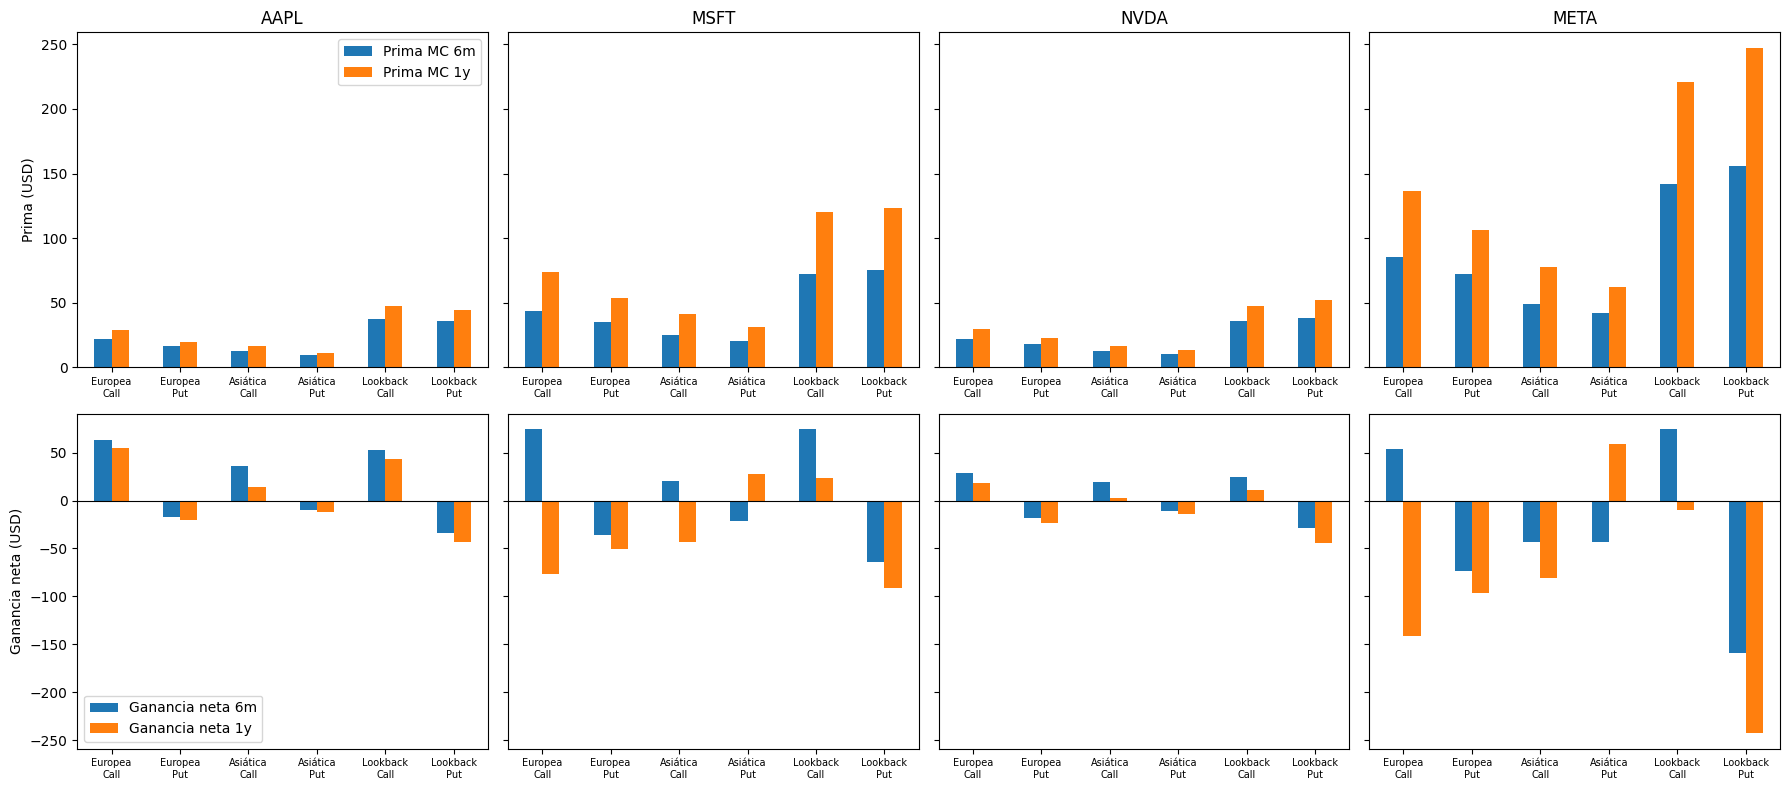

In [12]:
def comparar(precios_1y: pd.Series):
    """Valúa la misma acción con plazo de 1 año y de 6 meses. Regresa tabla y resumen."""
    precios_1y = precios_1y.dropna()
    inicio_6m = precios_1y.index[-1] - pd.DateOffset(months=6)
    precios_6m = precios_1y[precios_1y.index >= inicio_6m]

    tabla_6m, info_6m = valuar(precios_6m)
    tabla_1y, info_1y = valuar(precios_1y)

    tabla = tabla_6m[["Tipo", "Clase"]].copy()
    for col in ["Prima MC", "Payoff real", "Ganancia neta"]:
        tabla[f"{col} 6m"] = tabla_6m[col]
        tabla[f"{col} 1y"] = tabla_1y[col]
    # Rendimiento sobre la prima capitalizada a hoy (una opción que expira sin valor = -100 %)
    tabla["Rend. 6m"] = tabla_6m["Payoff real"] / (tabla_6m["Prima MC"] * np.exp(R * info_6m["T"])) - 1
    tabla["Rend. 1y"] = tabla_1y["Payoff real"] / (tabla_1y["Prima MC"] * np.exp(R * info_1y["T"])) - 1

    resumen = pd.DataFrame({"6 meses": info_6m, "1 año": info_1y}).T
    resumen["Var. acción"] = resumen["ST"] / resumen["S0"] - 1
    return tabla, resumen


if __name__ == "__main__":
    data = yf.download(tickers, period="1y", interval="1d", auto_adjust=True, progress=False)
    close = data["Close"]
    if close.dropna(how="all").empty:
        raise SystemExit("No se descargaron datos. Revisa tu conexión a internet (o un error de certificado SSL).")

    pd.set_option("display.float_format", "{:,.2f}".format)
    pd.set_option("display.width", 200)
    tablas = []
    for t in tickers:
        tabla, resumen = comparar(close[t])
        print(f"\n===================== {t} =====================")
        print(resumen[["S0", "ST", "Var. acción", "sigma", "T", "BS call", "BS put"]].to_string(
            formatters={"Var. acción": "{:.1%}".format, "sigma": "{:.1%}".format}))
        print()
        print(tabla.to_string(index=False, formatters={"Rend. 6m": "{:.0%}".format, "Rend. 1y": "{:.0%}".format}))
        tablas.append(tabla.assign(Ticker=t))

    todo = pd.concat(tablas)
    todo.to_csv("comparacion_6m_vs_1y.csv", index=False)
    print(f"\nTasa libre de riesgo usada: {R:.2%}. Resultados guardados en comparacion_6m_vs_1y.csv")

    # Gráficas: prima y ganancia neta, 6m vs 1y, por acción
    fig, axes = plt.subplots(2, len(tickers), figsize=(18, 8), sharey="row")
    for j, t in enumerate(tickers):
        d_filtered = todo[todo["Ticker"] == t]
        d = d_filtered.set_index(d_filtered["Tipo"] + "\n" + d_filtered["Clase"])
        d[["Prima MC 6m", "Prima MC 1y"]].plot.bar(ax=axes[0, j], legend=(j == 0), rot=0)
        d[["Ganancia neta 6m", "Ganancia neta 1y"]].plot.bar(ax=axes[1, j], legend=(j == 0), rot=0)
        axes[0, j].set_title(t)
        axes[1, j].axhline(0, color="black", linewidth=0.8)
        for ax in axes[:, j]:
            ax.tick_params(axis="x", labelsize=7)
            ax.set_xlabel("")
    axes[0, 0].set_ylabel("Prima (USD)")
    axes[1, 0].set_ylabel("Ganancia neta (USD)")
    plt.tight_layout()
    plt.show()


===================== AAPL =====================
S0 = 251.04 | mu = 1.97% | sigma = 21.21% | r = 4.00%
S_T real = 337.02 | S_T esperado = 253.80 | IC 90 % = [196.84, 320.22] | el real cayó en el percentil 98%
Black-Scholes -> Call: 17.48  Put: 12.51

    Tipo Clase  Prima (r)  Valor esperado (μ)  Payoff real  Ganancia neta Prob. pagar > 0 (μ)
 Europea  Call      17.35               15.91        85.98          68.27                 50%
 Europea   Put      12.12               13.21         0.00         -12.36                 50%
Asiática  Call       9.84                9.14        48.86          38.82                 50%
Asiática   Put       7.33                7.89         0.00          -7.47                 50%
Lookback  Call      29.40               27.92        90.83          60.84                 95%
Lookback   Put      26.22               27.27         2.77         -23.98                 95%

===================== MSFT =====================
S0 = 381.45 | mu = -54.36% | sigma = 26.

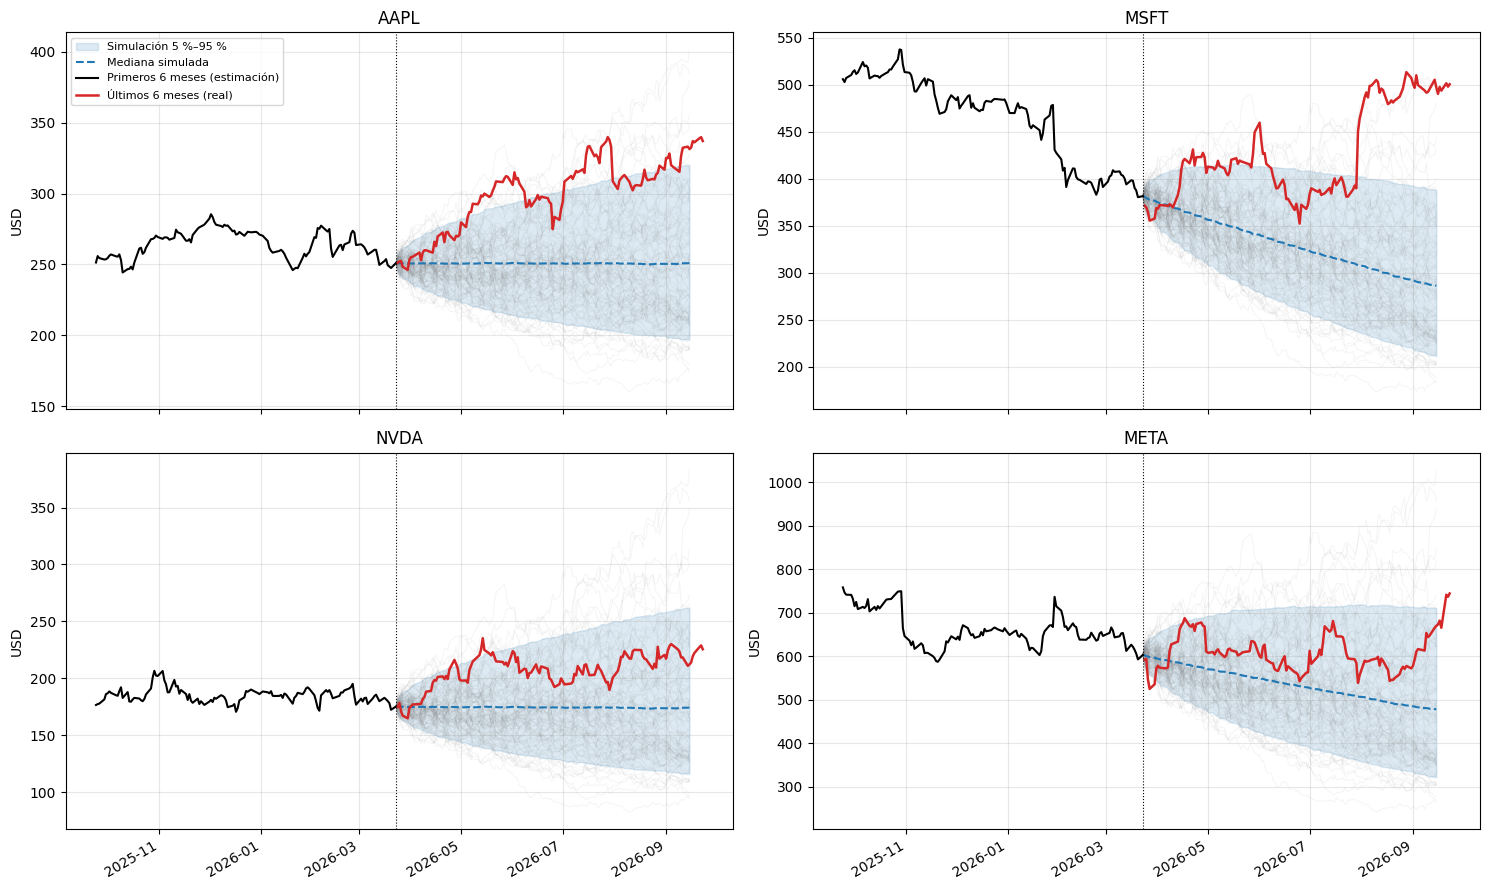

In [14]:
N_SIMS = 10_000
N_STEPS = 126      # días hábiles en 6 meses
SEED = 42


def estimar_parametros(precios: pd.Series):
    """Media y volatilidad de los rendimientos logarítmicos diarios, diarias y anualizadas."""
    rend = np.log(precios).diff().dropna()
    m, s = rend.mean(), rend.std()
    sigma = s * np.sqrt(252)
    mu = m * 252 + 0.5 * sigma**2      # drift del GBM: E[S_T] = S0·e^(mu·T)
    return m, s, mu, sigma


def simular(S0, m, s, n_steps=N_STEPS, n_sims=N_SIMS, seed=SEED):
    """GBM con incrementos log diarios ~ Normal(m, s). Regresa matriz (n_sims, n_steps + 1)."""
    rng = np.random.default_rng(seed)
    log_inc = m + s * rng.standard_normal((n_sims, n_steps))
    log_paths = np.cumsum(log_inc, axis=1)
    return S0 * np.exp(np.hstack([np.zeros((n_sims, 1)), log_paths]))


def analizar(precios_1y: pd.Series, r=R):
    precios_1y = precios_1y.dropna()
    corte = precios_1y.index[0] + pd.DateOffset(months=6)
    entrenamiento = precios_1y[precios_1y.index < corte]     # primeros 6 meses
    real = precios_1y[precios_1y.index >= corte]             # 6 meses restantes

    m, s, mu, sigma = estimar_parametros(entrenamiento)
    S0 = entrenamiento.iloc[-1]
    K = S0                                                   # at-the-money
    T = N_STEPS / 252
    dt = 1 / 252
    descuento = np.exp(-r * T)

    # Escenario 1: mundo real, drift = media estimada (pronóstico)
    tray_mu = simular(S0, m, s)
    # Escenario 2: neutral al riesgo, drift = r (precio teórico de la opción)
    m_rn = (r - 0.5 * sigma**2) * dt
    tray_rn = simular(S0, m_rn, s)

    pagos_mu = payoffs(tray_mu, K)
    pagos_rn = payoffs(tray_rn, K)
    pagos_real = payoffs(np.concatenate([[S0], real.to_numpy()]), K)

    filas = []
    for clave in pagos_mu:
        prima = descuento * pagos_rn[clave].mean()
        pago_real = pagos_real[clave][0]
        filas.append({
            "Tipo": clave[0],
            "Clase": clave[1],
            "Prima (r)": prima,
            "Valor esperado (μ)": descuento * pagos_mu[clave].mean(),
            "Payoff real": pago_real,
            "Ganancia neta": pago_real - prima / descuento,
            "Prob. pagar > 0 (μ)": (pagos_mu[clave] > 0).mean(),
        })
    tabla = pd.DataFrame(filas)

    ST_sim = tray_mu[:, -1]
    bs_call, bs_put = black_scholes(S0, K, r, sigma, T)
    info = {
        "S0": S0, "mu": mu, "sigma": sigma,
        "ST real": real.iloc[-1],
        "ST esperado": ST_sim.mean(),
        "ST p5": np.percentile(ST_sim, 5),
        "ST p95": np.percentile(ST_sim, 95),
        "Percentil del real": (ST_sim < real.iloc[-1]).mean(),
        "BS call": bs_call, "BS put": bs_put,
    }
    return tabla, info, entrenamiento, real, tray_mu


def graficar(ax, t, entrenamiento, real, tray, n_mostrar=100):
    fechas_sim = pd.bdate_range(start=entrenamiento.index[-1], periods=tray.shape[1])
    ax.plot(fechas_sim, tray[:n_mostrar].T, color="tab:gray", alpha=0.08, linewidth=0.7)
    p5, p50, p95 = np.percentile(tray, [5, 50, 95], axis=0)
    ax.fill_between(fechas_sim, p5, p95, color="tab:blue", alpha=0.15, label="Simulación 5 %–95 %")
    ax.plot(fechas_sim, p50, color="tab:blue", linestyle="--", label="Mediana simulada")
    ax.plot(entrenamiento.index, entrenamiento, color="black", label="Primeros 6 meses (estimación)")
    ax.plot(real.index, real, color="tab:red", linewidth=1.8, label="Últimos 6 meses (real)")
    ax.axvline(entrenamiento.index[-1], color="black", linestyle=":", linewidth=0.8)
    ax.set_title(t)
    ax.set_ylabel("USD")
    ax.grid(alpha=0.3)


if __name__ == "__main__":
    data = yf.download(tickers, period="1y", interval="1d", auto_adjust=True, progress=False)
    close = data["Close"]
    if close.dropna(how="all").empty:
        raise SystemExit("No se descargaron datos. Revisa tu conexión a internet (o un error de certificado SSL).")

    pd.set_option("display.float_format", "{:,.2f}".format)
    pd.set_option("display.width", 200)
    fig, axes = plt.subplots(2, 2, figsize=(15, 9))
    tablas = []
    for ax, t in zip(axes.flat, tickers):
        tabla, info, entrenamiento, real, tray = analizar(close[t])
        print(f"\n===================== {t} =====================")
        print(f"S0 = {info['S0']:.2f} | mu = {info['mu']:.2%} | sigma = {info['sigma']:.2%} | r = {R:.2%}")
        print(f"S_T real = {info['ST real']:.2f} | S_T esperado = {info['ST esperado']:.2f} | "
              f"IC 90 % = [{info['ST p5']:.2f}, {info['ST p95']:.2f}] | "
              f"el real cayó en el percentil {info['Percentil del real']:.0%}")
        print(f"Black-Scholes -> Call: {info['BS call']:.2f}  Put: {info['BS put']:.2f}\n")
        print(tabla.to_string(index=False, formatters={"Prob. pagar > 0 (μ)": "{:.0%}".format}))
        tablas.append(tabla.assign(Ticker=t))
        graficar(ax, t, entrenamiento, real, tray)

    pd.concat(tablas).to_csv("simulacion_6m.csv", index=False)
    print("\nResultados guardados en simulacion_6m.csv")

    axes[0, 0].legend(fontsize=8, loc="upper left")
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()


======================== AAPL ========================
mu:    estimada    2.0%  | realizada   62.2%
sigma: estimada   21.2%  | realizada   27.4%
Días con el precio real dentro de la banda 5–95 %: 49%

 Estadístico   Real  Media sim  p5 sim  p95 sim Percentil real  Dentro IC 90 %
Precio final 337.02     253.86  196.07   320.68            98%           False
 Rendimiento   0.34       0.01   -0.22     0.28            98%           False
      Máximo 339.79     282.00  251.04   334.08            96%           False
      Mínimo 246.19     225.33  189.01   251.04            86%            True
    Promedio 299.90     252.47  218.49   290.48            98%           False
Caída máxima  -0.13      -0.16   -0.27    -0.08            62%            True

    Tipo Clase  Prima (r)  Payoff medio sim  Payoff real Percentil real  Ganancia neta
 Europea  Call      17.56             16.43        85.98            98%          68.06
 Europea   Put      12.24             13.61         0.00            25

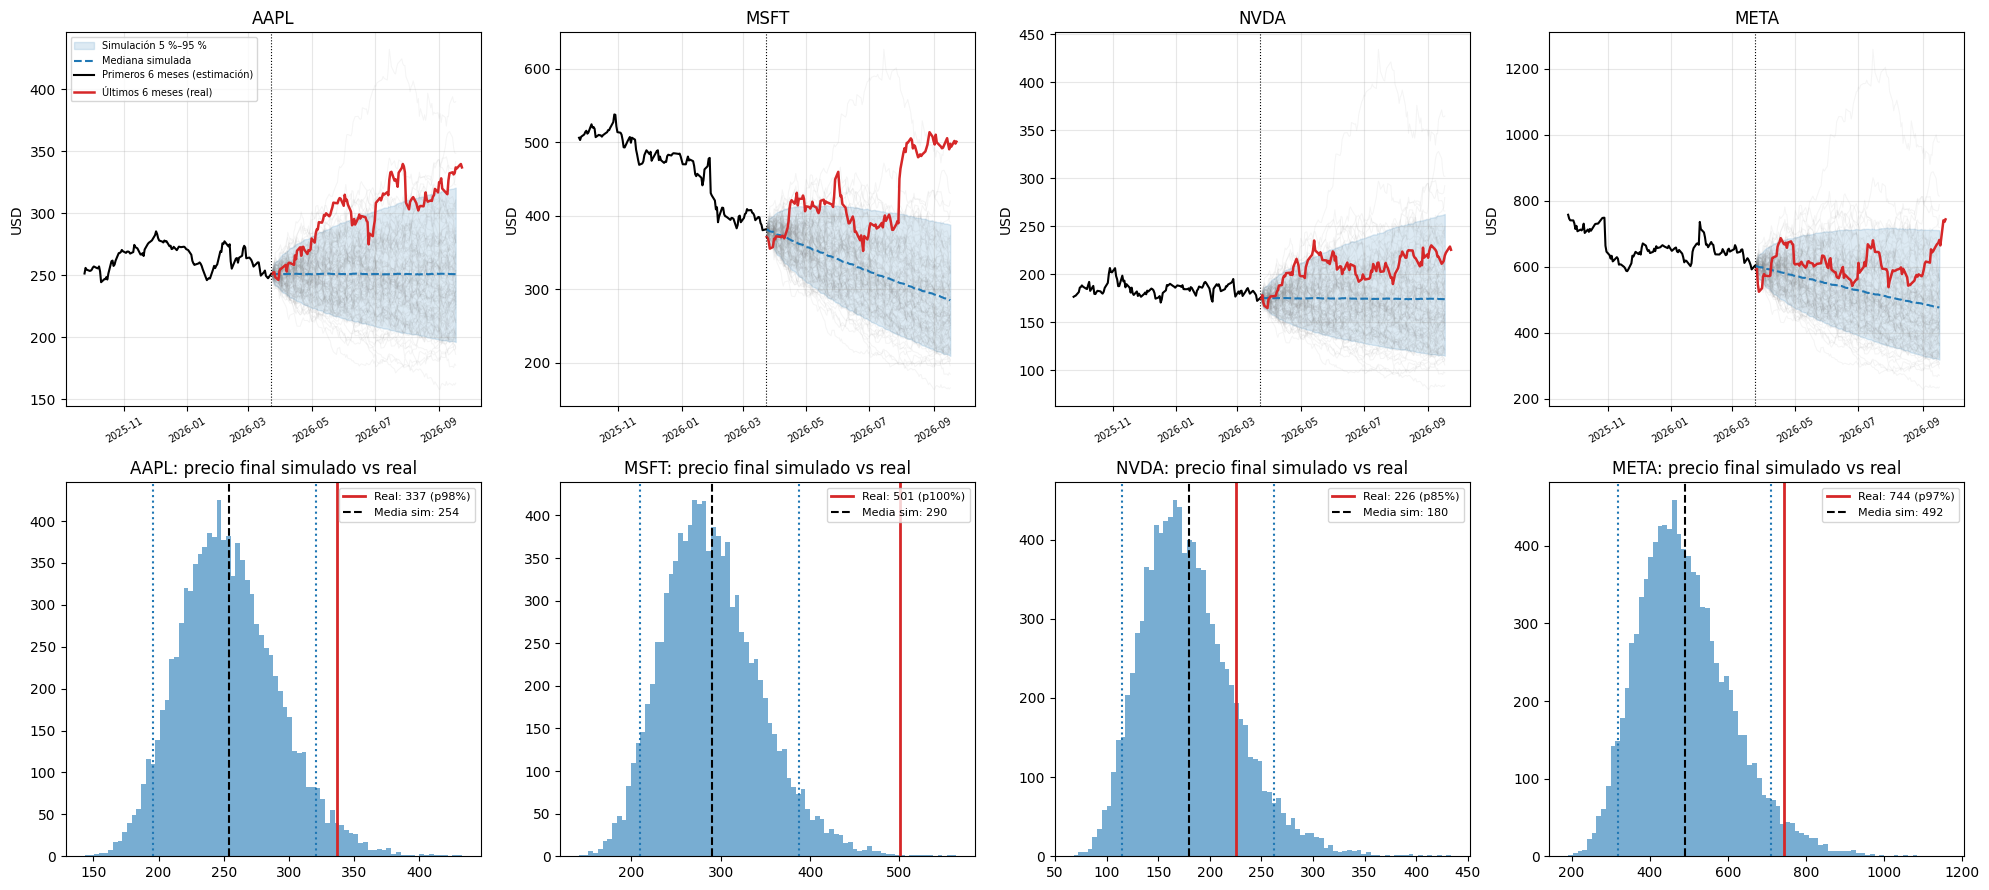

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# Global parameters
N_SIMS = 10_000
N_STEPS = 126      # días hábiles en 6 meses
SEED = 42
R = 0.04           # tasa libre de riesgo anual (ajústala a la tasa vigente)

# Function definitions from previous cells
def black_scholes(S0, K, r, sigma, T):
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    call = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    put = K * np.exp(-r * T) * norm.cdf(-d2) - S0 * norm.cdf(-d1)
    return call, put

def payoffs(paths, K):
    """Payoffs de cada tipo de opción. `paths` puede ser una sola trayectoria (1D) o muchas (2D)."""
    paths = np.atleast_2d(paths)
    ST = paths[:, -1]
    promedio = paths[:, 1:].mean(axis=1)   # Asiática: promedio aritmético, strike fijo K
    maximo = paths.max(axis=1)
    minimo = paths.min(axis=1)             # Lookback: strike flotante
    return {
        ("Europea", "Call"): np.maximum(ST - K, 0),
        ("Europea", "Put"): np.maximum(K - ST, 0),
        ("Asiática", "Call"): np.maximum(promedio - K, 0),
        ("Asiática", "Put"): np.maximum(K - promedio, 0),
        ("Lookback", "Call"): ST - minimo,
        ("Lookback", "Put"): maximo - ST,
    }

def estimar_parametros(precios: pd.Series):
    """Media y volatilidad de los rendimientos logarítmicos diarios, diarias y anualizadas."""
    rend = np.log(precios).diff().dropna()
    m, s = rend.mean(), rend.std()
    sigma = s * np.sqrt(252)
    mu = m * 252 + 0.5 * sigma**2      # drift del GBM: E[S_T] = S0·e^(mu·T)
    return m, s, mu, sigma

def simular(S0, m, s, n_steps=N_STEPS, n_sims=N_SIMS, seed=SEED):
    """GBM con incrementos log diarios ~ Normal(m, s). Regresa matriz (n_sims, n_steps + 1)."""
    rng = np.random.default_rng(seed)
    log_inc = m + s * rng.standard_normal((n_sims, n_steps))
    log_paths = np.cumsum(log_inc, axis=1)
    return S0 * np.exp(np.hstack([np.zeros((n_sims, 1)), log_paths]))

def analizar(precios_1y: pd.Series, r=R):
    precios_1y = precios_1y.dropna()
    corte = precios_1y.index[0] + pd.DateOffset(months=6)
    entrenamiento = precios_1y[precios_1y.index < corte]     # primeros 6 meses
    real = precios_1y[precios_1y.index >= corte]             # 6 meses restantes

    m, s, mu, sigma = estimar_parametros(entrenamiento)
    S0 = entrenamiento.iloc[-1]
    K = S0                                                   # at-the-money
    sim_n_steps = len(real) # Dynamic N_STEPS for simulation to match 'real' length
    T = sim_n_steps / 252
    dt = 1 / 252
    descuento = np.exp(-r * T)

    # Escenario 1: mundo real, drift = media estimada (pronóstico)
    tray_mu = simular(S0, m, s, n_steps=sim_n_steps)
    # Escenario 2: neutral al riesgo, drift = r (precio teórico de la opción)
    m_rn = (r - 0.5 * sigma**2) * dt
    tray_rn = simular(S0, m_rn, s, n_steps=sim_n_steps)

    pagos_mu = payoffs(tray_mu, K)
    pagos_rn = payoffs(tray_rn, K)
    pagos_real = payoffs(np.concatenate([[S0], real.to_numpy()]), K)

    filas = []
    for clave in pagos_mu:
        prima = descuento * pagos_rn[clave].mean()
        pago_real = pagos_real[clave][0]
        filas.append({
            "Tipo": clave[0],
            "Clase": clave[1],
            "Prima (r)": prima,
            "Valor esperado (μ)": descuento * pagos_mu[clave].mean(),
            "Payoff real": pago_real,
            "Ganancia neta": pago_real - prima / descuento,
            "Prob. pagar > 0 (μ)": (pagos_mu[clave] > 0).mean(),
        })
    tabla = pd.DataFrame(filas)

    ST_sim = tray_mu[:, -1]
    bs_call, bs_put = black_scholes(S0, K, r, sigma, T)
    info = {
        "S0": S0, "mu": mu, "sigma": sigma,
        "ST real": real.iloc[-1],
        "ST esperado": ST_sim.mean(),
        "ST p5": np.percentile(ST_sim, 5),
        "ST p95": np.percentile(ST_sim, 95),
        "Percentil del real": (ST_sim < real.iloc[-1]).mean(),
        "BS call": bs_call, "BS put": bs_put,
    }
    return tabla, info, entrenamiento, real, tray_mu


def graficar(ax, t, entrenamiento, real, tray, n_mostrar=100):
    fechas_sim = pd.bdate_range(start=entrenamiento.index[-1] + pd.Timedelta(days=1), periods=tray.shape[1])
    ax.plot(fechas_sim, tray[:n_mostrar].T, color="tab:gray", alpha=0.08, linewidth=0.7)
    p5, p50, p95 = np.percentile(tray, [5, 50, 95], axis=0)
    ax.fill_between(fechas_sim, p5, p95, color="tab:blue", alpha=0.15, label="Simulación 5 %–95 %")
    ax.plot(fechas_sim, p50, color="tab:blue", linestyle="--", label="Mediana simulada")
    ax.plot(entrenamiento.index, entrenamiento, color="black", label="Primeros 6 meses (estimación)")
    ax.plot(real.index, real, color="tab:red", linewidth=1.8, label="Últimos 6 meses (real)")
    ax.axvline(entrenamiento.index[-1], color="black", linestyle=":", linewidth=0.8)
    ax.set_title(t)
    ax.set_ylabel("USD")
    ax.grid(alpha=0.3)

def percentil(simulados, real):
    """Porcentaje de simulaciones por debajo del valor real (los empates cuentan la mitad)."""
    return (simulados < real).mean() + 0.5 * (simulados == real).mean()


if __name__ == "__main__":
    # `data` and `tickers` are assumed to be available from previous cells.

    close = data["Close"]
    pd.set_option("display.float_format", "{:,.2f}".format)
    pd.set_option("display.width", 200)

    resultados = {t: contrastar(close[t]) for t in tickers}
    resumen = []
    for t, res in resultados.items():
        p = res["parametros"]
        print(f"\n======================== {t} ========================")
        print(f"mu:    estimada {p['mu estimada']:7.1%}  | realizada {p['mu realizada']:7.1%}")
        print(f"sigma: estimada {p['sigma estimada']:7.1%}  | realizada {p['sigma realizada']:7.1%}")
        print(f"Días con el precio real dentro de la banda 5–95 %: {res['cobertura']:.0%}\n")
        print(res["stats"].to_string(index=False, formatters={
            "Percentil real": "{:.0%}".format}))
        print()
        print(res["opciones"].to_string(index=False, formatters={"Percentil real": "{:.0%}".format}))
        st = res["stats"].set_index("Estadístico")
        resumen.append({"Ticker": t, **p, "Rend. real": st.loc["Rendimiento", "Real"],
                        "Rend. esperado": st.loc["Rendimiento", "Media sim"],
                        "Percentil precio final": st.loc["Precio final", "Percentil real"],
                        "Cobertura banda": res["cobertura"]})

    resumen = pd.DataFrame(resumen).set_index("Ticker")
    print("\n======================== RESUMEN ========================")
    print(resumen.to_string(formatters={c: "{:.1%}".format for c in resumen.columns}))
    resumen.to_csv("contraste_resumen.csv")

    # Fila 1: trayectorias simuladas vs real. Fila 2: distribución del precio final vs real.
    fig, axes = plt.subplots(2, len(tickers), figsize=(20, 9))
    for j, (t, res) in enumerate(resultados.items()):
        graficar(axes[0, j], t, res["entrenamiento"], res["real_serie"], res["tray"])
        ax = axes[1, j]
        finales = res["tray"][:, -1]
        ax.hist(finales, bins=80, color="tab:blue", alpha=0.6)
        ax.axvline(res["real"][-1], color="tab:red", linewidth=2,
                   label=f"Real: {res['real'][-1]:.0f} (p{resumen.loc[t, 'Percentil precio final']:.0%})")
        ax.axvline(finales.mean(), color="black", linestyle="--", label=f"Media sim: {finales.mean():.0f}")
        for q in np.percentile(finales, [5, 95]):
            ax.axvline(q, color="tab:blue", linestyle=":")
        ax.set_title(f"{t}: precio final simulado vs real")
        ax.legend(fontsize=8)
    axes[0, 0].legend(fontsize=7, loc="upper left")
    for ax in axes[0]:
        ax.tick_params(axis="x", rotation=30, labelsize=7)
    plt.tight_layout()
    plt.savefig("contraste_simulacion.png", dpi=110)
    plt.show()